In [2]:
import torch
#.nn will automatically create a weight matrix for you which will be optimized during training
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
#Planetoid is a specific dataset loader provided by pytorch library
#instead of bulding our own adjacency matrix it gives us a downloadable dataobject 
from torch_geometric.nn import GCNConv
#Loading the dataset
dataset=Planetoid(root='/tmp/Cora',name='Cora')
data=dataset[0]
print(f"Dataset info:")
print(f"No of nodes:{data.num_nodes}")
print(f"No of features per node:{dataset.num_features}")
print(f"No of target communities/classes:{dataset.num_classes}")



Dataset info:
No of nodes:2708
No of features per node:1433
No of target communities/classes:7


what are these 1433 features per node ?? like instead of processing raw sentences or paragraphs converts the text of each academic paper into a binary vector of length 1433 i mean its a kind of dictonary if that word is present in the paper the node of the paper containing and at that work index it is kept as 1 or else 0

In [3]:
#defining the 2 layer architechture for GCN
class GCN(torch.nn.Module):
    def __init__(self,num_features,num_classes):
        super(GCN,self).__init__()
        self.conv1=GCNConv(num_features,16)
        #layer1 takes raw input features and converts them into an hidden 16d vector
        self.conv2=GCNConv(16,num_classes)
        #layer2 will convert those 16d vector of each node into 7d in this case which represents the probability of how much it belong to each category
    def forward(self,data):
        x,edge_index=data.x,data.edge_index
        #x is the feature matrix and edge_index is adjacency matrix stored in efficient way [2,no of edges]
        x=self.conv1(x,edge_index)
        x=F.relu(x)
        x=F.dropout(x,p=0.5,training=self.training)
        x=self.conv2(x,edge_index)
        return F.log_softmax(x,dim=1)
#the below steps are about setting up the execution environment 
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#cuda is a NVDIAs platform which allows pytorch to use GPU and we will use it if avaliable 
model=GCN(num_features=dataset.num_features,num_classes=dataset.num_classes).to(device)
#moving the weights to cuda VRAM if avaliable 
data=data.to(device)
#moving data also to VRAM if cuda is active 

optimizer=torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion=torch.nn.NLLLoss()



In [4]:
#training the model
#representing one single epoch
def train():
    model.train()
    optimizer.zero_grad() # removing the previous errors
    #farword pass
    out=model(data)
    loss=criterion(out[data.train_mask],data.y[data.train_mask])
    #backpropagating the loss to intial layers 
    loss.backward()
    #as we know the loss now we are trying to update the weights based on loss
    optimizer.step()
    return loss.item()

@torch.no_grad()
# we are doing this to turn off the memory engine while running the function 
# because while training in memort there will so my calculation for updating weight and calculating the loss but while testing we dont need all those 
def test():
    model.eval()
    out = model(data)
    pred = out.argmax(dim=1)  # Get the class with highest probability
    
    # Check predictions against true labels
    correct = pred == data.y
    
    # Calculate accuracy for training, validation, and testing splits
    train_acc = int(correct[data.train_mask].sum()) / int(data.train_mask.sum())
    val_acc = int(correct[data.val_mask].sum()) / int(data.val_mask.sum())
    test_acc = int(correct[data.test_mask].sum()) / int(data.test_mask.sum())
    
    return train_acc, val_acc, test_acc
#the train test split happens during the evaluation ohase is done by planetoid where it will create three binary hidden arrays and based on true or false
#of each node that node will be fallen into that category 

#running the model
for epoch in range(1, 201):
    loss = train()
    train_acc, val_acc, test_acc = test()
    
    if epoch % 20 == 0:
        print(f"Epoch: {epoch:d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")



Epoch: 20, Loss: 0.2398, Train Acc: 1.0000, Val Acc: 0.7680, Test Acc: 0.7830
Epoch: 40, Loss: 0.0759, Train Acc: 1.0000, Val Acc: 0.7680, Test Acc: 0.7780
Epoch: 60, Loss: 0.0518, Train Acc: 1.0000, Val Acc: 0.7720, Test Acc: 0.7870
Epoch: 80, Loss: 0.0439, Train Acc: 1.0000, Val Acc: 0.7720, Test Acc: 0.7850
Epoch: 100, Loss: 0.0445, Train Acc: 1.0000, Val Acc: 0.7760, Test Acc: 0.7960
Epoch: 120, Loss: 0.0400, Train Acc: 1.0000, Val Acc: 0.7720, Test Acc: 0.8040
Epoch: 140, Loss: 0.0287, Train Acc: 1.0000, Val Acc: 0.7720, Test Acc: 0.7980
Epoch: 160, Loss: 0.0267, Train Acc: 1.0000, Val Acc: 0.7720, Test Acc: 0.8020
Epoch: 180, Loss: 0.0259, Train Acc: 1.0000, Val Acc: 0.7760, Test Acc: 0.8040
Epoch: 200, Loss: 0.0196, Train Acc: 1.0000, Val Acc: 0.7580, Test Acc: 0.7940


In [5]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
#extracting the embeddings of each node of GCN
#we are extracting 16d vector output of first layer instead of final 7d because it is normalized one for getting category of papers
@torch.no_grad()
def get_embeddings(model, data):
    model.eval()
    # Manually pass through the first layer exactly like the forward function
    x = model.conv1(data.x, data.edge_index)
    x = torch.relu(x)
    # Move to CPU and convert to a standard NumPy array for Scikit-Learn
    return x.cpu().numpy()

# Extract the 16-dimensional vectors for all 2,708 nodes
embeddings = get_embeddings(model, data)
print(f"Extracted embeddings matrix shape: {embeddings.shape}")


Extracted embeddings matrix shape: (2708, 16)


In [6]:
#now we are going to use k means clustering on this cora dataset for community detection
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
cluster_assignments = kmeans.fit_predict(embeddings)
#here we are choosing no of clusters is 7 because we already know num_classes in cora dataset
#evaluating the community detection
true_labels = data.y.cpu().numpy()

# Compute evaluation scores
ari_score = adjusted_rand_score(true_labels, cluster_assignments)
nmi_score = normalized_mutual_info_score(true_labels, cluster_assignments)

print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")


Adjusted Rand Index (ARI): 0.5763
Normalized Mutual Information (NMI): 0.5699


The NMI mainly depends on entropy and uncertainity like it answers the question for us like if i know which cluster does the node belong to how much i am certain about its academin topic
suppose you are thorwing all 2300 nodes into 7 different bags and in bag 1 there should be onlt nodes belongs to category 1 and if by picking a node from bag1 how much certain are u it belongs to category 1 .
Normalized Mutual Information (NMI) measures the similarity between the ground-truth communities and the communities predicted by a clustering algorithm.

$$
\text{NMI}(\Omega, C) = \frac{I(\Omega; C)}{\sqrt{H(\Omega) \cdot H(C)}}
$$

Where:

- **$\Omega$ (Omega)**: Ground-truth partitioning (the actual community labels).
- **$C$**: Clustering partitioning generated by the algorithm (e.g., K-Means).
- **$I(\Omega; C)$ (Mutual Information)**: Measures how much information is shared between the true communities and the predicted communities. It quantifies how much uncertainty about the true labels is reduced when the predicted labels are known.
- **$H(\Omega)$ and $H(C)$ (Entropy)**: Measure the uncertainty or diversity within the true communities and predicted communities respectively.

The normalization term

$$
\sqrt{H(\Omega) \cdot H(C)}
$$

ensures that the score remains between **0 and 1**, making it easier to compare clustering results across different datasets.

### Interpretation

- **NMI = 1**: Perfect agreement between predicted and true communities.
- **NMI = 0**: No relationship between predicted and true communities.
- **0 < NMI < 1**: Partial agreement, with higher values indicating better clustering quality.

This should render correctly in both Jupyter Notebook and GitHub Markdown previews.

Running t-SNE (this might take a few seconds)...


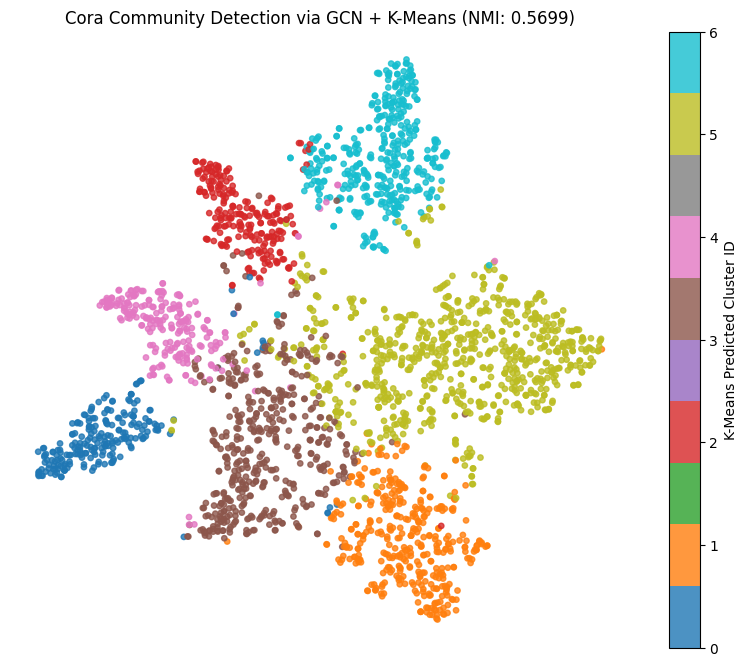

In [7]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import normalized_mutual_info_score
#reducing the dimensions to plot in graph
#SNE is a sort of dimensionality reduction technique
print("Running t-SNE (this might take a few seconds)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings)  # Shape becomes: (2708, 2)
#30 perplexity is no of nodes it is closely looking to covert into 2d
#plotting 
plt.figure(figsize=(10, 8))

# Scatter plot: X = column 0, Y = column 1
# c=cluster_assignments colors each dot by its K-Means predicted community
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=cluster_assignments,
    cmap="tab10",
    s=15,
    alpha=0.8,
)

plt.colorbar(scatter, label="K-Means Predicted Cluster ID")
plt.title(f"Cora Community Detection via GCN + K-Means (NMI: {nmi_score:.4f})")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.axis("off")  # Hides gridlines for a cleaner look
plt.show()

In [ ]:
import pandas as pd
#Testing whether changing the hidden dimension will change the 

#hidden dimensions that i wanted to test
hidden_dimensions_to_test = [4, 16, 32, 64, 128]

# Dictionary to store results for final reporting
experiment_results = {
    "Hidden Dimension": [], 
    "Final Test Accuracy": [], 
    "K-Means NMI": []
}

for hidden_dim in hidden_dimensions_to_test:
    print(f" Training with Hidden Dimension = {hidden_dim}")
    
    # re intializing the layers accoring to hidden dimension 
    model.conv1 = GCNConv(dataset.num_features, hidden_dim).to(device)
    model.conv2 = GCNConv(hidden_dim, dataset.num_classes).to(device)
    
    # Reset optimizer for the new weights
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    
    for epoch in range(1, 201):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        
    # evaluating the results 
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out.argmax(dim=1)
        correct = pred == data.y
        test_acc = int(correct[data.test_mask].sum()) / int(data.test_mask.sum())
        
    # extracting the embeddings afer layer 1 
    with torch.no_grad():
        hidden_embeddings = model.conv1(data.x, data.edge_index)
        hidden_embeddings = torch.relu(hidden_embeddings).cpu().numpy()
        
    # running k means algorithm on them for community detection 
    kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
    cluster_assignments = kmeans.fit_predict(hidden_embeddings)
    
    # results
    true_labels = data.y.cpu().numpy()
    nmi_score = normalized_mutual_info_score(true_labels, cluster_assignments)
    
    # appending the statistics 
    experiment_results["Hidden Dimension"].append(hidden_dim)
    experiment_results["Final Test Accuracy"].append(f"{test_acc * 100:.2f}%")
    experiment_results["K-Means NMI"].append(f"{nmi_score:.4f}")


print("             Final results            ")
df_results = pd.DataFrame(experiment_results)
print(df_results.to_string(index=False))


 Training with Hidden Dimension = 4
 Training with Hidden Dimension = 16
 Training with Hidden Dimension = 32
 Training with Hidden Dimension = 64
 Training with Hidden Dimension = 128
             Final results            
 Hidden Dimension Final Test Accuracy K-Means NMI
                4              68.00%      0.4246
               16              79.40%      0.5602
               32              80.80%      0.5576
               64              80.80%      0.5684
              128              79.50%      0.5627
